In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

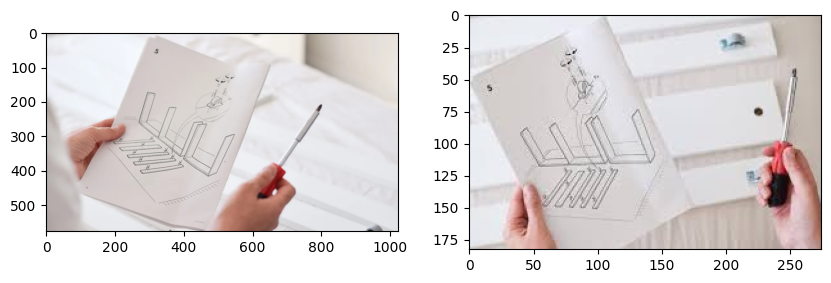

In [2]:
image1 = cv2.imread('image1.png')
image2 = cv2.imread('image2.jpeg')

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 8))
axes[0].imshow(cv2.cvtColor(image1, cv2.COLOR_BGR2RGB))
axes[1].imshow(cv2.cvtColor(image2, cv2.COLOR_BGR2RGB))

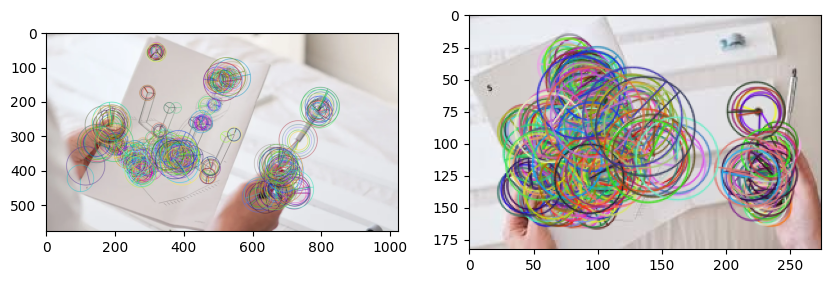

In [3]:
# inicializando o detector do orb
orb = cv2.ORB_create()

# detectando os keypoints nas imagens
kp1, des1 = orb.detectAndCompute(image1, None)
kp2, des2 = orb.detectAndCompute(image2, None)

image_1_kp = cv2.drawKeypoints(image1, kp1, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
image_2_kp = cv2.drawKeypoints(image2, kp2, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

ig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 8))
axes[0].imshow(cv2.cvtColor(image_1_kp, cv2.COLOR_BGR2RGB))
axes[1].imshow(cv2.cvtColor(image_2_kp, cv2.COLOR_BGR2RGB))

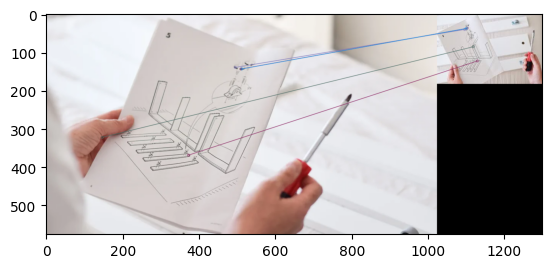

In [5]:
# criando matcher de força bruta
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

# Realizando matching entre descritores
matches = bf.match(des1, des2)

# Ordenando marches com menor distância
matches = sorted(matches, key = lambda x:x.distance)

# desenhar os 5 matches mais próximos
num = 5
image_matches = cv2.drawMatches(cv2.cvtColor(image1, cv2.COLOR_BGR2RGB), kp1, cv2.cvtColor(image2, cv2.COLOR_BGR2RGB), kp2, matches[:num],
                                None, flags=cv2.DRAW_MATCHES_FLAGS_NOT_DRAW_SINGLE_POINTS)

plt.imshow(image_matches)